In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report  , confusion_matrix

In [24]:
x,y = load_breast_cancer(return_X_y=True)  #return_X_y=True দিলে dataset সরাসরি X এবং y আলাদা করে দেয়
print('feature matrix shape: ',x.shape)
print('target vector shape: ',y.shape)

feature matrix shape:  (569, 30)
target vector shape:  (569,)


In [25]:
x_train , x_test,y_train,y_test = train_test_split(
    x,y, test_size=0.25 , random_state=42)
print('training sample: ',x_train.shape[0])
print('testing sample: ', x_test.shape[0])

training sample:  426
testing sample:  143


In [26]:
# Baseline model ( this gonna be used as weak learner)
stump = DecisionTreeClassifier(max_depth=1 , random_state=42)
stump.fit(x_train,y_train)
y_pred_stump = stump.predict(x_test)
print('Decision stump accuracy: ', accuracy_score(y_test, y_pred_stump))

Decision stump accuracy:  0.8951048951048951


In [27]:
# building AdaBoost model
base_learner = DecisionTreeClassifier(max_depth=1 , random_state=42)
ada = AdaBoostClassifier(
    estimator=base_learner, n_estimators=100 , learning_rate=0.3 , random_state=42
)
ada.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [28]:
y_pred_ada = ada.predict(x_test)
print('AdaBoost accuracy: ', accuracy_score(y_test, y_pred_ada))

AdaBoost accuracy:  0.958041958041958


In [30]:
print(classification_report(y_test , y_pred_ada))
print('Confusion matrix:\n', confusion_matrix(y_test , y_pred_ada))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143

Confusion matrix:
 [[51  3]
 [ 3 86]]


# Changes and their effects

Text(0.5, 1.0, 'Effect of n_estimators')

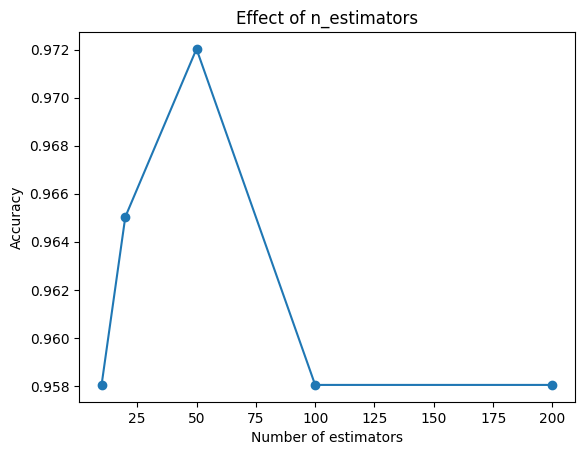

In [34]:
# Effect of number of estimators
estimators = [10,20,50,100,200]
accs=[]
for n in estimators:
    model = AdaBoostClassifier(
        estimator = base_learner,
        n_estimators = n,
        learning_rate = 0.3,
        random_state=42
    )
    model.fit(x_train , y_train)
    accs.append(accuracy_score(y_test, model.predict(x_test)))
    
plt.plot(estimators , accs , marker='o')
plt.xlabel('Number of estimators')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators')

Text(0.5, 1.0, 'Effect of Learning Rate')

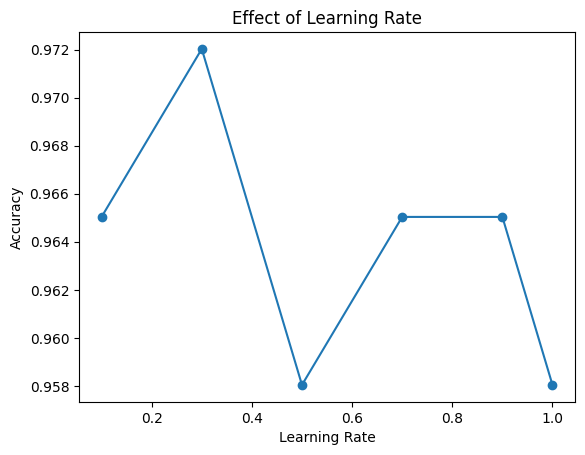

In [37]:
# Effect of Learning Rate
rates = [0.1 , 0.3, 0.5, 0.7,0.9,1]
accs_lr=[]
for lr in rates:
    model = AdaBoostClassifier(
        estimator = base_learner,
        n_estimators = 50,
        learning_rate = lr,
        random_state=42
    )
    model.fit(x_train , y_train)
    accs_lr.append(accuracy_score(y_test, model.predict(x_test)))
    
plt.plot(rates , accs_lr , marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate')

In [38]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for AdaBoost
param_grid = {
    'n_estimators': [20, 50, 100, 200],
    'learning_rate': [0.1, 0.3, 0.5, 0.7, 1.0],
    'estimator__max_depth': [1, 2]
}

# GridSearchCV setup
grid = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_learner,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Run grid search
grid.fit(x_train, y_train)

# Best model evaluation
best_model = grid.best_estimator_
y_pred_grid = best_model.predict(x_test)

print("Best Parameters Found:")
print(grid.best_params_)
print("\nTest Accuracy (GridSearch AdaBoost):",
      accuracy_score(y_test, y_pred_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid))

Best Parameters Found:
{'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 200}

Test Accuracy (GridSearch AdaBoost): 0.9790209790209791

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143

